# Test Forward Model

This notebook allows you to instantiate the `ForwardModel`, load the dataset, run a short training test, and visualize the predictions mapping the 10x10 impurity matrix to the transmission spectrum.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from forward_model import (
    ForwardGNRDataset,
    ForwardModel,
    train_forward_model,
    visualize_forward_prediction
)

print("Imports successful!")

Imports successful!


## 1. Setup Paths and Pristine Array

In [2]:
PROJECT_ROOT = Path(os.getcwd()).parents[1]
DATA_DIR     = PROJECT_ROOT / "data" / "raw" / "transmission_results"
MANIFEST_PATH = Path(os.getcwd()) / "manifest_agnr.csv"
PRISTINE_PATH = DATA_DIR / "pristine.npy"

try:
    pristine = np.load(str(PRISTINE_PATH))
    print(f"Pristine loaded, shape: {pristine.shape}")
except Exception as e:
    print(f"Failed to load pristine: {e}")
    pristine = np.ones(200)

Pristine loaded, shape: (300,)


## 2. Load Dataset

In [ ]:
dataset = ForwardGNRDataset(
    manifest_file=str(MANIFEST_PATH),
    root_dir=str(DATA_DIR),
    pristine=pristine,
    spectrum_length=200
)

# Check one item
x, y = dataset[0]
print(f"Input shape (Impurity Matrix): {x.shape}")
print(f"Target shape (Transmission): {y.shape}")

Loaded ForwardGNRDataset with 50000 samples (conc <= 10)
Input shape (Impurity Matrix): torch.Size([100])
Target shape (Transmission): torch.Size([200])


## 3. Train Model
Uncomment the cell below to verify training behavior. By default, it runs for 5 epochs to demonstrate functionality.

Training on device: cpu
Epoch 001/50 | Train MSE: 0.0308 | Val MSE: 0.0309
Epoch 002/50 | Train MSE: 0.0313 | Val MSE: 0.0314
Epoch 003/50 | Train MSE: 0.0313 | Val MSE: 0.0313
Epoch 004/50 | Train MSE: 0.0313 | Val MSE: 0.0313
Epoch 005/50 | Train MSE: 0.0313 | Val MSE: 0.0313
Epoch 006/50 | Train MSE: 0.0313 | Val MSE: 0.0316
Epoch 007/50 | Train MSE: 0.0315 | Val MSE: 0.0315
Epoch 008/50 | Train MSE: 0.0314 | Val MSE: 0.0315
Epoch 009/50 | Train MSE: 0.0314 | Val MSE: 0.0314
Epoch 010/50 | Train MSE: 0.0314 | Val MSE: 0.0314
Epoch 011/50 | Train MSE: 0.0313 | Val MSE: 0.0311
Epoch 012/50 | Train MSE: 0.0310 | Val MSE: 0.0311
Epoch 013/50 | Train MSE: 0.0310 | Val MSE: 0.0311
Epoch 014/50 | Train MSE: 0.0310 | Val MSE: 0.0310
Epoch 015/50 | Train MSE: 0.0310 | Val MSE: 0.0310
Epoch 016/50 | Train MSE: 0.0302 | Val MSE: 0.0302
Epoch 017/50 | Train MSE: 0.0285 | Val MSE: 0.0277
Epoch 018/50 | Train MSE: 0.0279 | Val MSE: 0.0277
Epoch 019/50 | Train MSE: 0.0276 | Val MSE: 0.0277
Epoch 0

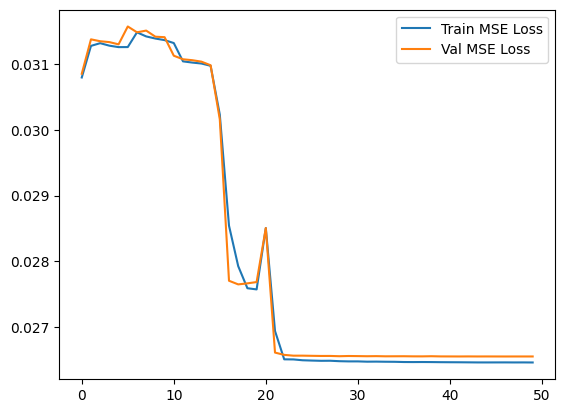

In [6]:
model, train_losses, val_losses = train_forward_model(dataset, num_epochs=50, batch_size=64, lr=1e-3)

plt.plot(train_losses, label="Train MSE Loss")
plt.plot(val_losses, label="Val MSE Loss")
plt.legend()
plt.show()

## 4. Visualize Forward Prediction
Once the model is built (or trained), you can visualize what the distance matrix target structures map to.

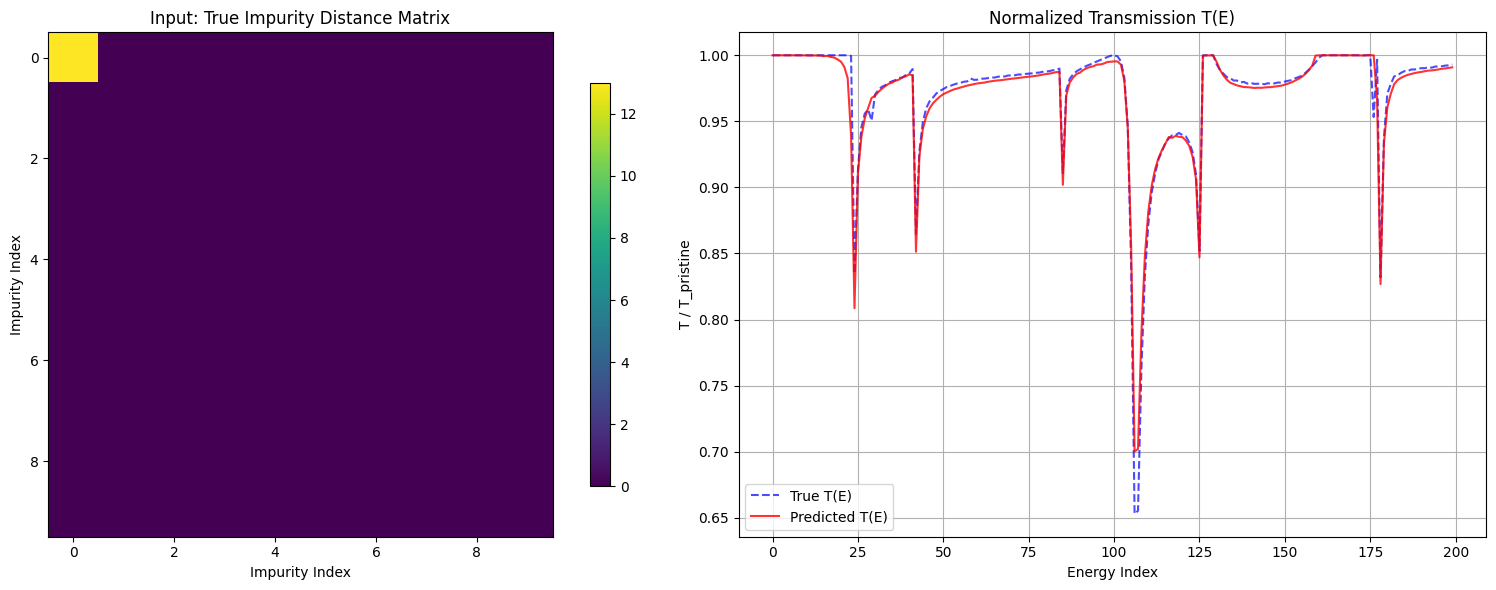

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# If you didn't execute the previous training cell, instantiate an untrained model to test the plotting logic:
try:
    model
except NameError:
    model = ForwardModel().to(device)

visualize_forward_prediction(model, dataset, idx=50, max_conc=10)